In [1]:
pip install -U langchain langchain-experimental langchain-groq pandas tabulate


  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 4.8 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 2.9 MB/s eta 0:00:01
   ---------------------------- ----------- 1.8/2.5 MB 3.1 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 2.9 MB/s  0:00:00
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 3.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.7 MB 3.3 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.7 MB 3.2 MB/s eta 0:00:03
   ----------- ----------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.2 which is incompatible.


In [2]:
import os
import getpass #hidden
import pandas as pd
from langchain_groq import ChatGroq
from langchain_experimental.agents import create_csv_agent

In [3]:
os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key:  ········


In [5]:
CSV_PATH = r"D:\GITHUB\Learning-tasks\students\Tejasvi\Gopuff-market-analysis\gopuff_data.csv"   # replace with your file
df = pd.read_csv(r"D:\GITHUB\Learning-tasks\students\Tejasvi\Gopuff-market-analysis\gopuff_data.csv")

print(df.head())  # preview data

  Item Fat Content Item Identifier              Item Type  \
0          Regular           FDX32  Fruits and Vegetables   
1          Low Fat           NCB42     Health and Hygiene   
2          Regular           FDR28           Frozen Foods   
3          Regular           FDL50                 Canned   
4          Low Fat           DRI25            Soft Drinks   

   Outlet Establishment Year Outlet Identifier Outlet Location Type  \
0                       2012            OUT049               Tier 1   
1                       2022            OUT018               Tier 3   
2                       2010            OUT046               Tier 1   
3                       2000            OUT013               Tier 3   
4                       2015            OUT045               Tier 2   

  Outlet Size        Outlet Type  Item Visibility  Item Weight     Sales  \
0      Medium  Supermarket Type1         0.100014        15.10  145.4786   
1      Medium  Supermarket Type2         0.008596     

In [7]:
from langchain_experimental.agents import create_csv_agent
from langchain_groq import ChatGroq

In [28]:
from langchain_groq import ChatGroq

groq_chat = ChatGroq(
    model="llama-3.3-70b-versatile",  # ✅ NEW MODEL
    temperature=0
)

In [29]:
agent = create_csv_agent(
    llm=groq_chat,
    path=CSV_PATH,
    verbose=True,
    allow_dangerous_code=True
)

In [30]:
agent.invoke("How many rows and columns are in this dataset?")



> Entering new AgentExecutor chain...
Thought: To find the number of rows and columns in the dataset, I can use the `shape` attribute of the pandas DataFrame.

Action: python_repl_ast
Action Input: print(df.shape)(8523, 12)
The `shape` attribute of a pandas DataFrame returns a tuple representing the dimensionality of the DataFrame. The first element of the tuple is the number of rows, and the second element is the number of columns.

Thought: I now know the final answer
Final Answer: The dataset contains 8523 rows and 12 columns.

> Finished chain.


{'input': 'How many rows and columns are in this dataset?',
 'output': 'The dataset contains 8523 rows and 12 columns.'}

In [31]:
agent.invoke("What are the column names?")



> Entering new AgentExecutor chain...
Thought: To find the column names of the dataframe `df`, I can use the `columns` attribute of the dataframe.

Action: python_repl_ast
Action Input: print(df.columns)Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')
I now know the final answer

Final Answer: The column names of the dataframe `df` are: 
1. Item Fat Content
2. Item Identifier
3. Item Type
4. Outlet Establishment Year
5. Outlet Identifier
6. Outlet Location Type
7. Outlet Size
8. Outlet Type
9. Item Visibility
10. Item Weight
11. Sales
12. Rating

> Finished chain.


{'input': 'What are the column names?',
 'output': 'The column names of the dataframe `df` are: \n1. Item Fat Content\n2. Item Identifier\n3. Item Type\n4. Outlet Establishment Year\n5. Outlet Identifier\n6. Outlet Location Type\n7. Outlet Size\n8. Outlet Type\n9. Item Visibility\n10. Item Weight\n11. Sales\n12. Rating'}

In [32]:
agent.invoke("Give me a summary of the dataset")



> Entering new AgentExecutor chain...
Thought: To get a summary of the dataset, I should use the `describe()` function in pandas, which provides a concise summary of the central tendency, dispersion, and shape of a dataset’s distribution.

Action: python_repl_ast
Action Input: `print(df.describe())`       Outlet Establishment Year  Item Visibility  Item Weight        Sales  \
count                8523.000000      8523.000000  7060.000000  8523.000000   
mean                 2010.831867         0.066132    12.857645   140.992782   
std                     8.371760         0.051598     4.643456    62.275067   
min                  1998.000000         0.000000     4.555000    31.290000   
25%                  2000.000000         0.026989     8.773750    93.826500   
50%                  2012.000000         0.053931    12.600000   143.012800   
75%                  2017.000000         0.094585    16.850000   185.643700   
max                  2022.000000         0.328391    21.350000   2

{'input': 'Give me a summary of the dataset',
 'output': "The dataset contains 8523 entries across 12 columns. The numerical columns include 'Outlet Establishment Year', 'Item Visibility', 'Item Weight', 'Sales', and 'Rating'. The 'Item Weight' column has 7060 non-null entries, while the rest of the numerical columns have 8523 non-null entries. The dataset also includes 7 string columns. The central tendency, dispersion, and shape of the dataset's distribution for the numerical columns are as follows: \n- 'Outlet Establishment Year' has a mean of 2010.83, a standard deviation of 8.37, a minimum of 1998, a maximum of 2022, and quartiles of 2000, 2012, and 2017.\n- 'Item Visibility' has a mean of 0.066, a standard deviation of 0.051, a minimum of 0, a maximum of 0.328, and quartiles of 0.027, 0.054, and 0.095.\n- 'Item Weight' has a mean of 12.86, a standard deviation of 4.64, a minimum of 4.555, a maximum of 21.35, and quartiles of 8.773, 12.6, and 16.85.\n- 'Sales' has a mean of 140.99

In [33]:
agent.invoke("Find any missing values")



> Entering new AgentExecutor chain...
Thought: To find any missing values in the dataframe `df`, I should use the `isnull()` function provided by pandas, which returns a boolean mask indicating missing values.

Action: python_repl_ast
Action Input: `print(df.isnull().sum())`Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64
The output of `print(df.isnull().sum())` shows the number of missing values in each column of the dataframe. 

Thought: From the observation, I can see that there are no missing values in most columns, but there are 1463 missing values in the 'Item Weight' column.

Action: python_repl_ast
Action Input

{'input': 'Find any missing values',
 'output': "There are 1463 missing values in the 'Item Weight' column of the dataframe `df`. All other columns have no missing values."}

In [34]:
def ask(question):
    print("Question:", question)
    print("-" * 50)
    response = agent.invoke(question)
    print(response["output"] if isinstance(response, dict) else response)

In [35]:
ask("What is the average of sales column?")

Question: What is the average of sales column?
--------------------------------------------------


> Entering new AgentExecutor chain...
Thought: To find the average of the 'Sales' column in the dataframe `df`, I can use the `mean()` function provided by pandas.

Action: python_repl_ast
Action Input: `print(df['Sales'].mean())`140.9927819781767
I now know the final answer

Final Answer: The average of the 'Sales' column is 140.9927819781767.

> Finished chain.
The average of the 'Sales' column is 140.9927819781767.


Question: Generate Pie chart?
--------------------------------------------------


> Entering new AgentExecutor chain...
Thought: To generate a pie chart, we first need to decide what column in the dataframe we want to use for the chart. Since a pie chart is typically used to show the proportion of different categories, we should choose a column with categorical data. The 'Item Type' column seems like a good choice.

Action: python_repl_ast
Action Input: ```python
import matplotlib.pyplot as plt
print(df['Item Type'].value_counts())```
Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 11

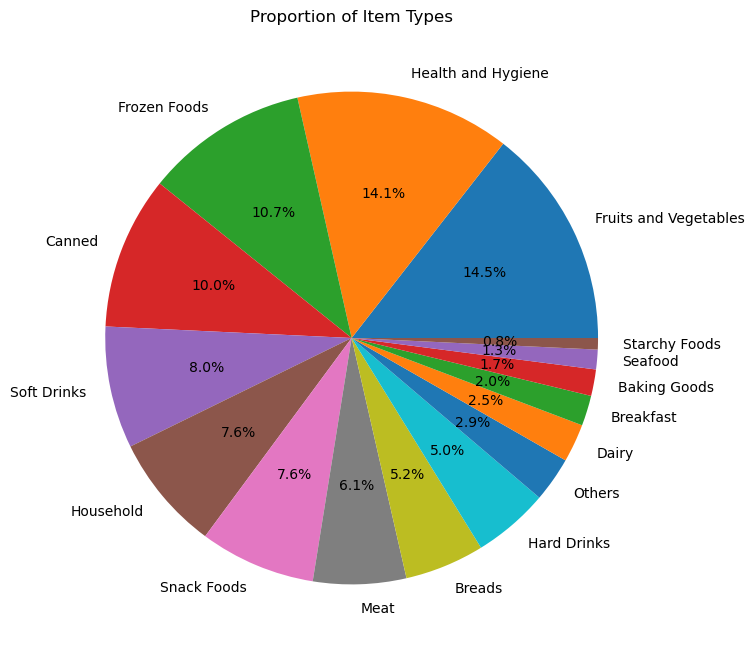

I now know the final answer

Final Answer: A pie chart has been generated, showing the proportion of different 'Item Type' categories in the dataframe. The chart displays the percentage of each category, with the largest proportion being 'Fruits and Vegetables' and the smallest being 'Seafood'.

> Finished chain.
A pie chart has been generated, showing the proportion of different 'Item Type' categories in the dataframe. The chart displays the percentage of each category, with the largest proportion being 'Fruits and Vegetables' and the smallest being 'Seafood'.


In [36]:
ask("Generate Pie chart?")

Question: Generate bar chart?
--------------------------------------------------


> Entering new AgentExecutor chain...
Thought: To generate a bar chart, we first need to decide which column(s) of the dataframe we want to plot. Since the problem doesn't specify, let's start by getting an overview of the dataframe to see which columns might be suitable for a bar chart.

Action: python_repl_ast
Action Input: print(df.columns)Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')
From the output of `print(df.columns)`, we can see that there are several columns that could potentially be used for a bar chart. However, since a bar chart typically requires a categorical variable on the x-axis and a numerical variable on the y-axis, let's look for columns that fit these criteria.

Action: pytho

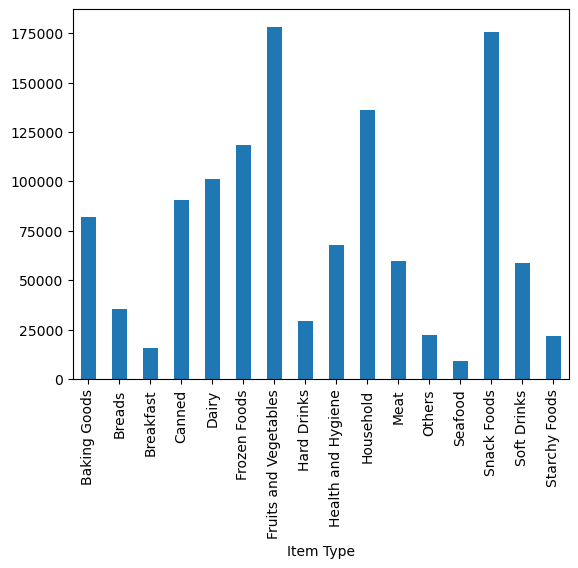

I now know the final answer

Final Answer: The bar chart is generated using the 'Item Type' column on the x-axis and the 'Sales' column on the y-axis. The chart displays the total sales for each item type. 

Note: The actual chart is not displayed here as it is a visual representation, but the code provided can be used to generate the chart. 

Here is the code:
```python
import matplotlib.pyplot as plt
df.groupby('Item Type')['Sales'].sum().plot(kind='bar')
plt.show()
```

> Finished chain.
The bar chart is generated using the 'Item Type' column on the x-axis and the 'Sales' column on the y-axis. The chart displays the total sales for each item type. 

Note: The actual chart is not displayed here as it is a visual representation, but the code provided can be used to generate the chart. 

Here is the code:
```python
import matplotlib.pyplot as plt
df.groupby('Item Type')['Sales'].sum().plot(kind='bar')
plt.show()
```


In [37]:
ask("Generate bar chart?")